# Logistic Regression with NumPy
Binary tweet sentiment classification — TF-IDF and gradient descent using numpy only, no sklearn.

## 1. Load & Preprocess Tweets

In [1]:
import nltk
nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.corpus import twitter_samples, stopwords
import numpy as np
import pandas as pd
import re
import random
from collections import Counter

STOPWORDS = set(stopwords.words('english'))

def clean(text: str) -> list:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return [t for t in text.split() if t not in STOPWORDS and len(t) > 1]

pos_tweets = twitter_samples.strings('positive_tweets.json')
neg_tweets = twitter_samples.strings('negative_tweets.json')

texts  = pos_tweets + neg_tweets
labels = [1] * len(pos_tweets) + [0] * len(neg_tweets)
tokens = [clean(t) for t in texts]

# Shuffle together — raw data is ordered (all pos then all neg),
# so an unshuffled 80/20 split would put ~all negatives in the test set.
combined = list(zip(tokens, labels))
random.seed(42)
random.shuffle(combined)
tokens, labels = zip(*combined)
tokens, labels = list(tokens), list(labels)

print(f"Total tweets: {len(texts):,}  |  Pos: {sum(labels):,}  Neg: {labels.count(0):,}")

Total tweets: 10,000  |  Pos: 5,000  Neg: 5,000


## 2. Train / Test Split (80/20)

In [2]:
split = int(len(tokens) * 0.8)

train_tokens, test_tokens = tokens[:split], tokens[split:]
y_train = np.array(labels[:split], dtype=np.float64)
y_test  = np.array(labels[split:], dtype=np.float64)

print(f"Train: {len(train_tokens):,}  |  Test: {len(test_tokens):,}")
print(f"Train — Pos: {int(y_train.sum()):,}  Neg: {int((y_train==0).sum()):,}")
print(f"Test  — Pos: {int(y_test.sum()):,}  Neg: {int((y_test==0).sum()):,}")

Train: 8,000  |  Test: 2,000
Train — Pos: 3,994  Neg: 4,006
Test  — Pos: 1,006  Neg: 994


## 3. Build Vocabulary

In [3]:
VOCAB_SIZE = 3000

freq     = Counter(tok for doc in train_tokens for tok in doc)
vocab    = [w for w, _ in freq.most_common(VOCAB_SIZE)]
word2idx = {w: i for i, w in enumerate(vocab)}

print(f"Vocabulary size: {len(vocab):,}  |  Top 10: {vocab[:10]}")

Vocabulary size: 3,000  |  Top 10: ['im', 'follow', 'thanks', 'like', 'love', 'please', 'get', 'dont', 'good', 'day']


## 4. TF-IDF Vectoriser from Scratch (NumPy)

$$TF(t,d) = \frac{\text{count}(t,d)}{|d|} \qquad IDF(t) = \log\!\left(\frac{1+N}{1+df(t)}\right)+1$$

Each document row is L2-normalised after computing TF-IDF.

In [4]:
def fit_idf(token_lists, vocab, word2idx):
    N  = len(token_lists)
    df = np.zeros(len(vocab))
    for doc in token_lists:
        for word in set(doc):
            if word in word2idx:
                df[word2idx[word]] += 1
    return np.log((1 + N) / (1 + df)) + 1.0   # shape (V,)


def tfidf_transform(token_lists, vocab, word2idx, idf):
    n = len(token_lists)
    V = len(vocab)
    X = np.zeros((n, V), dtype=np.float32)

    for i, doc in enumerate(token_lists):
        if not doc:
            continue
        cnt = Counter(doc)
        for word, count in cnt.items():
            if word in word2idx:
                j       = word2idx[word]
                X[i, j] = (count / len(doc)) * idf[j]   # TF * IDF

        # L2 normalisation
        norm = np.linalg.norm(X[i])
        if norm > 0:
            X[i] /= norm

    return X


idf = fit_idf(train_tokens, vocab, word2idx)

print("Building TF-IDF matrices...")
X_train = tfidf_transform(train_tokens, vocab, word2idx, idf)
X_test  = tfidf_transform(test_tokens,  vocab, word2idx, idf)

# Add bias column
X_train = np.column_stack([np.ones(len(X_train)), X_train])
X_test  = np.column_stack([np.ones(len(X_test)),  X_test])

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

Building TF-IDF matrices...
X_train: (8000, 3001)  |  X_test: (2000, 3001)


---
# Logistic Regression via Gradient Descent

**Sigmoid:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Binary Cross-Entropy loss:**
$$J(\beta) = -\frac{1}{n} \left[ y^T \log(\hat{p}) + (1-y)^T \log(1-\hat{p}) \right]$$

**Gradient:**
$$\nabla J = \frac{1}{n} X^T (\hat{p} - y)$$

**Update:**
$$\beta \leftarrow \beta - \alpha \cdot \nabla J$$

## 5. Sigmoid

In [5]:
def sigmoid(z):
    # clip prevents overflow in exp
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

## 6. Training Loop

In [6]:
def logistic_gd(X, y, lr=0.1, epochs=500, log_every=50):
    """
    Batch Gradient Descent for Logistic Regression.

    Forward:   p_hat = sigmoid(X @ beta)
    Loss:      BCE   = -mean(y*log(p) + (1-y)*log(1-p))
    Gradient:  grad  = (1/n) * X.T @ (p_hat - y)
    Update:    beta -= lr * grad
    """
    n, p   = X.shape
    beta   = np.zeros(p)
    losses = []

    for epoch in range(1, epochs + 1):
        p_hat    = sigmoid(X @ beta)                                    # (n,)
        p_clip   = np.clip(p_hat, 1e-15, 1 - 1e-15)                    # avoid log(0)
        loss     = -np.mean(y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))
        gradient = (1 / n) * X.T @ (p_hat - y)                         # (p,)
        beta    -= lr * gradient
        losses.append(loss)

        if epoch % log_every == 0 or epoch == 1:
            acc = np.mean((p_hat >= 0.5).astype(int) == y)
            print(f"Epoch {epoch:>4} | Loss: {loss:.6f} | Train Acc: {acc:.4f}")

    return beta, losses


beta, loss_history = logistic_gd(X_train, y_train, lr=0.5, epochs=300, log_every=50)

Epoch    1 | Loss: 0.693147 | Train Acc: 0.4993
Epoch   50 | Loss: 0.684490 | Train Acc: 0.7405
Epoch  100 | Loss: 0.676249 | Train Acc: 0.7528
Epoch  150 | Loss: 0.668555 | Train Acc: 0.7582
Epoch  200 | Loss: 0.661359 | Train Acc: 0.7596
Epoch  250 | Loss: 0.654617 | Train Acc: 0.7620
Epoch  300 | Loss: 0.648287 | Train Acc: 0.7648


## 7. Loss Curve

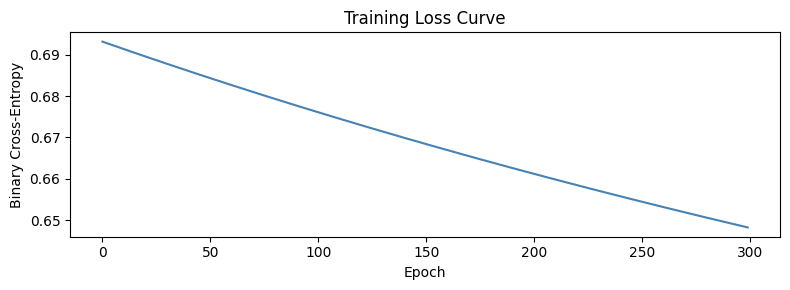

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy')
plt.title('Training Loss Curve')
plt.tight_layout()
plt.show()

## 8. Evaluation

In [8]:
def evaluate(X, y_true, beta, label):
    p_hat  = sigmoid(X @ beta)
    y_pred = (p_hat >= 0.5).astype(int)
    acc    = np.mean(y_pred == y_true)

    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"{label:<6} | Acc: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    return y_pred

evaluate(X_train, y_train, beta, 'Train')
y_pred_test = evaluate(X_test,  y_test,  beta, 'Test')

Train  | Acc: 0.7648 | Precision: 0.8335 | Recall: 0.6607 | F1: 0.7372
Test   | Acc: 0.7180 | Precision: 0.7805 | Recall: 0.6113 | F1: 0.6856


## 9. Confusion Matrix

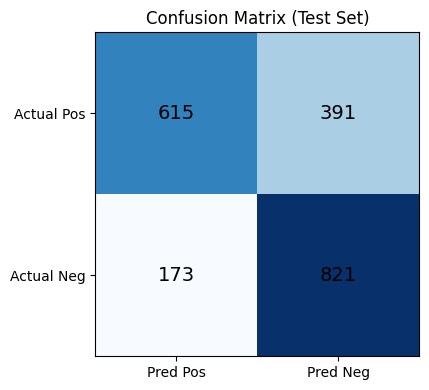

In [9]:
tp = np.sum((y_pred_test == 1) & (y_test == 1))
tn = np.sum((y_pred_test == 0) & (y_test == 0))
fp = np.sum((y_pred_test == 1) & (y_test == 0))
fn = np.sum((y_pred_test == 0) & (y_test == 1))

cm = np.array([[tp, fn], [fp, tn]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Pos', 'Pred Neg'])
ax.set_yticklabels(['Actual Pos', 'Actual Neg'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='black')
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## 10. Top Predictive Words

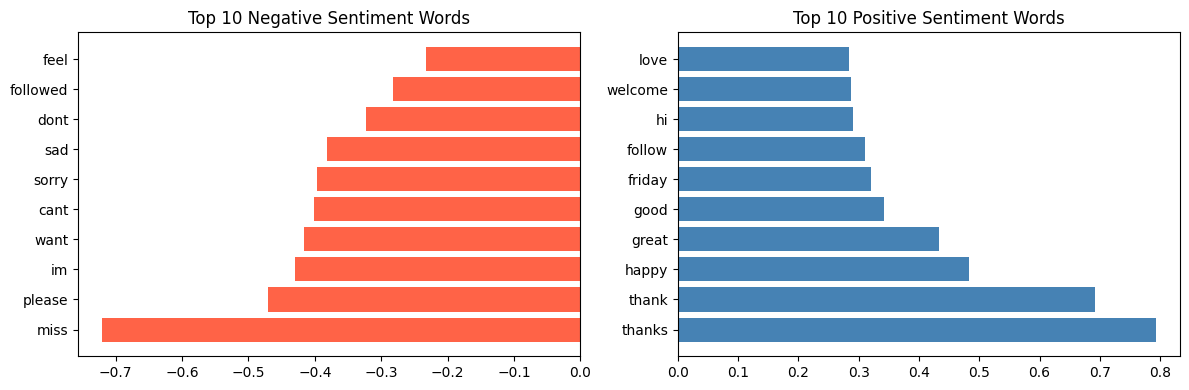

In [10]:
# beta[0] is the bias — skip it
coef  = beta[1:]
order = np.argsort(coef)

top_neg_words = [vocab[i] for i in order[:10]]
top_pos_words = [vocab[i] for i in order[-10:][::-1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.barh(top_neg_words, coef[order[:10]],  color='tomato')
ax1.set_title('Top 10 Negative Sentiment Words')
ax2.barh(top_pos_words, coef[order[-10:][::-1]], color='steelblue')
ax2.set_title('Top 10 Positive Sentiment Words')
plt.tight_layout()
plt.show()

## 11. Predict on a Custom Tweet

In [11]:
def predict_tweet(tweet, beta, vocab, word2idx, idf):
    toks  = clean(tweet)
    vec   = tfidf_transform([toks], vocab, word2idx, idf)   # (1, V)
    vec_b = np.column_stack([np.ones(1), vec])               # add bias
    prob  = sigmoid(vec_b @ beta)[0]
    label = 'Positive 😊' if prob >= 0.5 else 'Negative 😞'
    print(f"Tweet:       {tweet}")
    print(f"Probability: {prob:.4f}")
    print(f"Sentiment:   {label}")

predict_tweet("I love this so much, absolutely amazing!", beta, vocab, word2idx, idf)
print()
predict_tweet("This is the worst day ever, I hate everything.", beta, vocab, word2idx, idf)

Tweet:       I love this so much, absolutely amazing!
Probability: 0.5275
Sentiment:   Positive 😊

Tweet:       This is the worst day ever, I hate everything.
Probability: 0.4866
Sentiment:   Negative 😞


## Save Model to `../Models/`

In [12]:
import os

save_path = '../Models/logreg_numpy.npz'
np.savez_compressed(
    save_path,
    vocab = np.array(vocab),   # (V,) string array of vocabulary
    idf   = idf,               # (V,) float array of IDF weights
    beta  = beta               # (V+1,) float array — beta[0] is bias
)

size_kb = os.path.getsize(save_path) / 1024
print(f"Saved → {save_path}  ({size_kb:.1f} KB)")

Saved → ../Models/logreg_numpy.npz  (43.1 KB)
